In [155]:
#import libraries for the data analysis and visualization
import pandas as pd # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For data visualization using plots
import seaborn as sns  # For advanced visualizations and styling
from sklearn.model_selection import train_test_split # to split the dataset in to train and test set
from sklearn.linear_model import LinearRegression # to train the model


In [156]:
# Importing and Exploring the Dataset
# Load the dataset
dataset = pd.read_csv('colorectal_cancer_prediction.csv')
# Check the structure and types of data columns
print(dataset.info())

dataset.loc[dataset['Recurrence'] == 'No', 'Time_to_Recurrence'] = 0

#check to see if there are any null values
print("\n checking if there's NaN")
print(dataset.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  object 
 3   Race                     89945 non-null  object 
 4   Region                   89945 non-null  object 
 5   Urban_or_Rural           89945 non-null  object 
 6   Socioeconomic_Status     89945 non-null  object 
 7   Family_History           89945 non-null  object 
 8   Previous_Cancer_History  89945 non-null  object 
 9   Stage_at_Diagnosis       89945 non-null  object 
 10  Tumor_Aggressiveness     89945 non-null  object 
 11  Colonoscopy_Access       89945 non-null  object 
 12  Screening_Regularity     89945 non-null  object 
 13  Diet_Type                89945 non-null  object 
 14  BMI                   

In [157]:
#based on our analysis, we concluded that the variable 'Patient_ID' does not contribute to the future prediction that'll be conducted
#therefore we decided to drop the variable.
dataset.drop('Patient_ID', axis=1, inplace=True)

#select a random selective sample from the data and define it as 'data' for simpler clarity (remove this and change top if we need the whole set)
#rewrite data into ds (we used random sampling for this.)
data = dataset.sample(n=383, replace=False, random_state=44)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 383 entries, 88452 to 59504
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      383 non-null    int64  
 1   Gender                   383 non-null    object 
 2   Race                     383 non-null    object 
 3   Region                   383 non-null    object 
 4   Urban_or_Rural           383 non-null    object 
 5   Socioeconomic_Status     383 non-null    object 
 6   Family_History           383 non-null    object 
 7   Previous_Cancer_History  383 non-null    object 
 8   Stage_at_Diagnosis       383 non-null    object 
 9   Tumor_Aggressiveness     383 non-null    object 
 10  Colonoscopy_Access       383 non-null    object 
 11  Screening_Regularity     383 non-null    object 
 12  Diet_Type                383 non-null    object 
 13  BMI                      383 non-null    float64
 14  Physical_Activity_Level  

In [158]:
#SPLITTING THE DATASET (splitting into independant (X) and dependant (Y) variables) for each dependant variable

X_og = data.iloc[:, :-3].values #select all rows and all columns except the last  since the last are independant variables
Y1_og = data.iloc[:, -3].values #select all rows and only the last column (third last)
Y2_og = data.iloc[:, -2].values #select all rows and only the last column (second last)
Y3_og = data.iloc[:, -1].values #select all rows and only the last column (last)

#we're putting _og to the data to diffrentiate between the encoded and the pure untouched ones

#DISPLAY X AND Y
print("Independent Variables (X): ")
print(X_og[:5])  # Display first 5 rows only

print("\nDependent Variable survival status (Y1): ")
print(Y1_og[:5])  # Display first 5 rows only
print("\nDependent Variables recurrance (Y2): ")
print(Y2_og[:5])
print("\nDependent Variables time to recuurance (Y3): ")
print(Y3_og[:5])

#in project .head() or .tail() when displaying

Independent Variables (X): 
[[61 'Male' 'White' 'Asia Pacific' 'Rural' 'Middle' 'No' 'No' 'IV' 'Low'
  'Yes' 'Never' 'Balanced' 25.4 'Medium' 'Current' 'High' 'Low' 'Low'
  'No' 'Timely' 'Good' 'No' 'No' 'Yes' 'Good']
 [20 'Male' 'Black' 'Europe' 'Urban' 'Middle' 'Yes' 'No' 'II' 'Low' 'Yes'
  'Irregular' 'Western' 30.5 'Low' 'Current' 'Low' 'High' 'Low' 'Yes'
  'Timely' 'Good' 'No' 'No' 'Yes' 'Poor']
 [29 'Female' 'Hispanic' 'North America' 'Urban' 'Low' 'Yes' 'No' 'IV'
  'Low' 'Yes' 'Regular' 'Western' 33.1 'High' 'Former' 'Low' 'High'
  'High' 'Yes' 'Delayed' 'Limited' 'Yes' 'Yes' 'Yes' 'Poor']
 [44 'Female' 'White' 'Asia Pacific' 'Urban' 'Middle' 'No' 'No' 'IV'
  'High' 'Yes' 'Irregular' 'Balanced' 33.4 'High' 'Never' 'Low' 'Medium'
  'Low' 'No' 'Timely' 'Good' 'No' 'No' 'No' 'Good']
 [30 'Male' 'White' 'Europe' 'Rural' 'Middle' 'Yes' 'No' 'I' 'Low' 'Yes'
  'Never' 'Western' 24.1 'Low' 'Current' 'Low' 'High' 'High' 'No'
  'Timely' 'Limited' 'No' 'No' 'Yes' 'Good']]

Dependent Variab

In [159]:
#ENCODE THE DEPENDANT VARIABLES USING LABEL ENCODER TO CONVERT THE CATEGORICAL VALUES TO NUMERICAL
#OK

#import LabelEncoder to convert categorical variables to numerical values
from sklearn.preprocessing import LabelEncoder

#create instance of LabelEncoder Class
le = LabelEncoder()

#fit the LabelEncoder to categorical dependent variable and transform it to numeric
Y1 = le.fit_transform(Y1_og)  # Survival_Status

#display the dataset Y1 after transforming
print("\nAfter encoding the dependant variable (Y1 - Survival_Status): ")
print(Y1)

#fit the LabelEncoder to categorical dependent variable and transform it to numeric
Y2 = le.fit_transform(Y2_og)  # Recurrence

#display the dataset Y2 after transforming
print("\nAfter encoding the dependant variable (Y2 - Recurrence): ")
print(Y2)

#Y3 is already numerical and continuous (Time_to_Recurrence), no encoding needed for regression
Y3 = Y3_og

# BUT: for classification, we convert Y3 into binary classes (e.g. 0 = Early, 1 = Late)
# Define a threshold (e.g. 12 months cutoff)
Y3_cat = (Y3 > 12).astype(int)

print("\nAfter converting Y3 into binary classes for classification (0 = early, 1 = late): ")
print(Y3_cat)



After encoding the dependant variable (Y1 - Survival_Status): 
[1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 0 0 0
 1 1 1 0 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1
 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 0 0
 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0 1
 1 0 1 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1
 0 0 1 1 1 1 1 0 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1
 0 0 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0
 1 0 1 1 1 1 1 0 1 0 1 0 1 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1
 1 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 1 0 0 0 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]

After encoding the dependant variable (Y2 - Recurrence): 
[0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1
 1 0 1 0 1 0 1 0 0 1 0 0

In [160]:
#ENCODE THE INDEPENDENT VARIABLES USING ONEHOT ENCODER TO CONVERT CATEGORICAL VALUES TO NUMERICAL
#GOOD

#importing ColumnTransformer to apply transformations to specific columns
from sklearn.compose import ColumnTransformer

#import the OneHotEncoder to convert categorical data to numeric value
from sklearn.preprocessing import OneHotEncoder

# Exclude the last 3 columns (dependent variables)
independent_data = data.iloc[:, :-3]

# Apply OneHotEncoder to all object-type columns automatically
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(sparse_output=False, drop='first'), independent_data.select_dtypes(include='object').columns)],
    remainder='passthrough'
)

# Transform the independent data
X = ct.fit_transform(independent_data)

#display the dataset X after transforming
print("\nAfter transforming the categorical data to numerical (independent variables): ")
print(X)



After transforming the categorical data to numerical (independent variables): 
[[ 1.   0.   0.  ...  0.  61.  25.4]
 [ 1.   1.   0.  ...  1.  20.  30.5]
 [ 0.   0.   1.  ...  1.  29.  33.1]
 ...
 [ 1.   0.   0.  ...  1.  26.  19.1]
 [ 0.   0.   0.  ...  0.  87.  18.9]
 [ 1.   0.   0.  ...  0.  67.  28.4]]


In [161]:
#splitting the dataset
#import the train_test_split to split dta into traing and testing
from sklearn.model_selection import train_test_split

# Combine all Ys together temporarily
import numpy as np
Y_all = np.column_stack((Y1, Y2, Y3))

# Now split ONCE
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_all, test_size=0.2, random_state=44)

# Then separate them back
Y1_train = Y_train[:, 0]  # Survival_Status
Y2_train = Y_train[:, 1]  # Recurrence
Y3_train = Y_train[:, 2]  # Time_to_Recurrence

Y1_test = Y_test[:, 0]
Y2_test = Y_test[:, 1]
Y3_test = Y_test[:, 2]

#split the dataset into training(80%) and testing (20%)
#random state = 1 ensures reproduciyy of the split (to maintain consistans in the results everytime)
#  test_size=0.2 means 20% of data is for testing

#display the split data
print("\n training set for X, X_train: ")
print(X_train[:5])
print("\n test set for X, X_test:  ")
print(X_test[:5])


print("\n training set for Y1, Y1_train: ")
print(Y1_train[:5])
print("\n test set for Y1, Y1_test: " )
print(Y1_test[:5])


print("\n training set for Y2, Y2_train: ")
print(Y2_train[:5])
print("\n test set for Y2, Y2_test: " )
print(Y2_test[:5])


print("\n training set for Y3, Y3_train: ")
print(Y3_train[:5])
print("\n test set for Y3, Y3_test: " )
print(Y3_test[:5])


 training set for X, X_train: 
[[ 0.   0.   0.   1.   0.   0.   0.   0.   1.   1.   0.   1.   0.   0.
   0.   1.   0.   1.   0.   1.   0.   1.   0.   0.   0.   1.   0.   1.
   0.   1.   0.   1.   0.   1.   0.   1.   0.   1.   0.   1.   1.  87.
  33.8]
 [ 1.   0.   0.   0.   1.   0.   0.   1.   0.   1.   0.   1.   0.   0.
   0.   0.   0.   0.   0.   1.   0.   0.   0.   1.   1.   0.   0.   1.
   1.   0.   0.   1.   1.   0.   0.   0.   0.   1.   1.   1.   1.  73.
  19.1]
 [ 1.   0.   0.   0.   1.   0.   1.   0.   0.   1.   0.   1.   1.   0.
   0.   0.   0.   1.   0.   0.   1.   0.   0.   1.   1.   0.   1.   0.
   0.   1.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  81.
  25.9]
 [ 1.   1.   0.   0.   0.   0.   1.   0.   0.   1.   0.   0.   0.   0.
   0.   0.   1.   0.   1.   1.   0.   1.   0.   1.   1.   0.   0.   1.
   1.   0.   0.   1.   1.   0.   1.   1.   0.   0.   0.   1.   0.  78.
  33.2]
 [ 1.   0.   1.   0.   0.   0.   1.   0.   0.   1.   0.   1.   1.   0.
   0.   1.   

In [162]:
#]

In [163]:
#import SAtandardScaler for normalization [u dont need normalization if the values are 1-0]
#just scale the categorical
from sklearn.preprocessing import StandardScaler
sc = StandardScaler() #create and instance of Standard Scaler

#fit the strandardscaler to the training ser - columns from index 3 and onwards and transform it
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test) #tranform bc its only 1 column

#strandardize (X - mean)/Standard devation
print("\n Strandadized X train set: ")
print(X_train_scaled)
print("\n Strandadized X test set: ")
print(X_test_scaled)

# Decision Tree does NOT require scaling; you can use X directly.


 Strandadized X train set: 
[[-1.08176373 -0.45769659 -0.37655152 ...  1.32542701  1.5593735
   0.69645536]
 [ 0.92441628 -0.45769659 -0.37655152 ...  1.32542701  0.88431731
  -1.65602305]
 [ 0.92441628 -0.45769659 -0.37655152 ... -0.75447384  1.27006371
  -0.56780174]
 ...
 [ 0.92441628 -0.45769659 -0.37655152 ... -0.75447384 -0.22470358
  -0.71183104]
 [-1.08176373 -0.45769659 -0.37655152 ... -0.75447384  0.16104282
   0.50441631]
 [-1.08176373 -0.45769659 -0.37655152 ...  1.32542701  1.22184541
   1.17655299]]

 Strandadized X test set: 
[[ 0.92441628 -0.45769659 -0.37655152 ... -0.75447384  0.98075391
  -0.50378873]
 [-1.08176373 -0.45769659 -0.37655152 ...  1.32542701 -1.28550617
  -0.7598408 ]
 [ 0.92441628 -0.45769659 -0.37655152 ... -0.75447384 -1.47837937
   0.02431867]
 ...
 [-1.08176373 -0.45769659 -0.37655152 ...  1.32542701  0.40213432
  -1.35196121]
 [ 0.92441628 -0.45769659 -0.37655152 ... -0.75447384  1.17362711
  -0.19972689]
 [ 0.92441628 -0.45769659 -0.37655152 ... 

In [164]:
# After scaling
print("Train means:", X_train_scaled.mean(axis=0))  # Should be ~0
print("Train stds:", X_train_scaled.std(axis=0))    # Should be ~1
print("Test means:", X_test_scaled.mean(axis=0))    # Should NOT be 0

Train means: [ 1.45127193e-18 -2.50344408e-17  1.12473574e-17  9.28814034e-17
  5.80508771e-18 -7.80058661e-18  3.19279824e-17 -1.58188640e-16
  1.03765943e-16  1.44401557e-16  1.19004298e-16  0.00000000e+00
 -5.80508771e-18 -1.29526020e-16 -3.30164364e-17  1.27711930e-16
 -1.69073180e-16  1.24083750e-16 -6.67585087e-17 -7.83686841e-17
  2.53972587e-17  0.00000000e+00  1.08845395e-18  1.53834824e-16
  4.06356140e-17  3.04767105e-17  2.16239517e-16  7.61917762e-17
 -6.53072367e-17 -1.93744802e-16 -5.65996052e-17 -2.78644210e-16
  2.24221513e-16 -3.48305263e-17 -2.75741666e-16  1.45127193e-18
 -3.48305263e-17  9.57839472e-17 -1.67621908e-16 -1.11747938e-16
  4.13612499e-17 -8.41737718e-17  2.68485307e-15]
Train stds: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Test means: [ 0.1427877   0.0570859  -0.02213495 -0.02922078 -0.02589136 -0.10383324
  0.09556712  0.29486435 -0.1656851  -0.10159336  0.089476

Discreptive statistics

In [165]:
#create a function for descriptive statistics (numerical)

def Desc_stat(ds,var):
  mean=ds[var].mean()
  median=ds[var].median()
  mode=ds[var].mode()
  minimum=ds[var].min()
  maximum=ds[var].max()
  range=ds[var].max() - ds[var].min()
  std_dev=ds[var].std()
  variance=ds[var].var()
  skew=ds[var].skew()
  kurtosis=ds[var].kurt()
  count=ds[var].count()
  Quart = [
            ds[var].quantile(0),
            ds[var].quantile(0.25),
            ds[var].quantile(0.50),
            ds[var].quantile(0.75),
            ds[var].quantile(1),
            ds[var].quantile(0.75) - ds[var].quantile(0.25)
          ]

  summary = {
      "Descriptive Statistics": var,
              "Average ": mean,
             "Median ": median,
             "Mode ": mode,
             "Minimum ": minimum,
             "Maximim ": maximum,
             "Range ": range,
             "Std Dev ": std_dev,
             "Variance ": variance,
             "Skewness ": skew,
             "Kurtosis ": kurtosis,
             "Minimum ": Quart[0],
             "25th Pecentile ": Quart[1],
             "50th Pecentile ": Quart[2],
             "75th Pecentile ": Quart[3],
             "Maximum ": Quart[4],
             "Inter Quartile Range ": Quart[5],
             "Count ": count

            }
  return summary



In [166]:
def Desc_stat_categorical(ds, var, label_map=None):
    print(f"\nDescriptive Stats for: {var}")
    print("-" * 40)

    # Print basic info
    print(f"Data Type        : {ds[var].dtype}")
    print(f"Count            : {ds[var].count()}")
    print(f"Missing          : {ds[var].isnull().sum()}")
    print(f"Unique Values    : {ds[var].nunique()}")

    # Apply mapping if provided
    if label_map:
        mapped_series = ds[var].map(label_map)
    else:
        mapped_series = ds[var]

    # Frequency Table
    print("\nFrequency Table:")
    print(mapped_series.value_counts().sort_index())


In [167]:
# Full dataset, no sampling
# (No need for np.random or X_sample_indices)

# Desc stat for Survival_Status
Desc_stat_categorical(pd.DataFrame(Y1_og, columns=['Survival_Status']), 'Survival_Status')

# Desc stat for Recurrence
Desc_stat_categorical(pd.DataFrame(Y2_og, columns=['Recurrence']), 'Recurrence')

# Desc stat for Time_to_Recurrence
Desc_stat(pd.DataFrame(Y3_og, columns=['Time_to_Recurrence']), 'Time_to_Recurrence')



Descriptive Stats for: Survival_Status
----------------------------------------
Data Type        : object
Count            : 383
Missing          : 0
Unique Values    : 2

Frequency Table:
Survival_Status
Deceased    112
Survived    271
Name: count, dtype: int64

Descriptive Stats for: Recurrence
----------------------------------------
Data Type        : object
Count            : 383
Missing          : 0
Unique Values    : 2

Frequency Table:
Recurrence
No     267
Yes    116
Name: count, dtype: int64


{'Descriptive Statistics': 'Time_to_Recurrence',
 'Average ': np.float64(8.809399477806789),
 'Median ': 0.0,
 'Mode ': 0    0
 Name: Time_to_Recurrence, dtype: int64,
 'Minimum ': np.float64(0.0),
 'Maximim ': 59,
 'Range ': 59,
 'Std Dev ': 16.28871434716241,
 'Variance ': 265.32221508345464,
 'Skewness ': np.float64(1.732137809310585),
 'Kurtosis ': np.float64(1.6850818349300982),
 '25th Pecentile ': np.float64(0.0),
 '50th Pecentile ': np.float64(0.0),
 '75th Pecentile ': np.float64(11.0),
 'Maximum ': np.float64(59.0),
 'Inter Quartile Range ': np.float64(11.0),
 'Count ': np.int64(383)}

In [168]:
np.random.seed(44) # Lock the random selection so the sample doesnt change
X_sample_indices = np.random.choice(X_og.shape[0], size=150, replace=False)
X_sample = X_og[X_sample_indices] #we use indices to match the samples from the X with the other Y's

y1_sample = Y1_og[X_sample_indices]
Desc_stat_categorical(pd.DataFrame(y1_sample, columns=['Survival_Status']), 'Survival_Status')

y2_sample = Y2_og[X_sample_indices]
Desc_stat_categorical(pd.DataFrame(y2_sample, columns=['Recurrence']), 'Recurrence')

y3_sample = Y3_og[X_sample_indices]
Desc_stat(pd.DataFrame(y3_sample, columns=['Time_to_Recurrence']), 'Time_to_Recurrence')


Descriptive Stats for: Survival_Status
----------------------------------------
Data Type        : object
Count            : 150
Missing          : 0
Unique Values    : 2

Frequency Table:
Survival_Status
Deceased     50
Survived    100
Name: count, dtype: int64

Descriptive Stats for: Recurrence
----------------------------------------
Data Type        : object
Count            : 150
Missing          : 0
Unique Values    : 2

Frequency Table:
Recurrence
No     102
Yes     48
Name: count, dtype: int64


{'Descriptive Statistics': 'Time_to_Recurrence',
 'Average ': np.float64(9.026666666666667),
 'Median ': 0.0,
 'Mode ': 0    0
 Name: Time_to_Recurrence, dtype: int64,
 'Minimum ': np.float64(0.0),
 'Maximim ': 59,
 'Range ': 59,
 'Std Dev ': 16.09866669483005,
 'Variance ': 259.1670693512303,
 'Skewness ': np.float64(1.6935346497313817),
 'Kurtosis ': np.float64(1.6555162130438914),
 '25th Pecentile ': np.float64(0.0),
 '50th Pecentile ': np.float64(0.0),
 '75th Pecentile ': np.float64(12.75),
 'Maximum ': np.float64(59.0),
 'Inter Quartile Range ': np.float64(12.75),
 'Count ': np.int64(150)}

In [169]:
# Systematic Sampling
step = 5  # You can change this value based on your needs or conditions
start = 0  # Starting index (can be randomized or fixed)

# Generate indices for systematic sampling
X_sample_indices = np.arange(start, X.shape[0], step)
X_sample_s = X_og[X_sample_indices]

# Dependent variable 1 - Categorical
print("\n Survival_staus")
y1_sample_s = Y1_og[X_sample_indices]
Desc_stat_categorical(pd.DataFrame(y1_sample, columns=['Survival_Status']), 'Survival_Status')

# Dependent variable 2 - Categorical
print("\n Recurrence")
y2_sample_s = Y2_og[X_sample_indices]
Desc_stat_categorical(pd.DataFrame(y2_sample, columns=['Recurrence']), 'Recurrence')

# Dependent variable 3 - Numerical
print("\n Time_to_recurrence")
y3_sample_s = Y3_og[X_sample_indices]
Desc_stat(pd.DataFrame(y3_sample, columns=['Time_to_Recurrence']), 'Time_to_Recurrence')



 Survival_staus

Descriptive Stats for: Survival_Status
----------------------------------------
Data Type        : object
Count            : 150
Missing          : 0
Unique Values    : 2

Frequency Table:
Survival_Status
Deceased     50
Survived    100
Name: count, dtype: int64

 Recurrence

Descriptive Stats for: Recurrence
----------------------------------------
Data Type        : object
Count            : 150
Missing          : 0
Unique Values    : 2

Frequency Table:
Recurrence
No     102
Yes     48
Name: count, dtype: int64

 Time_to_recurrence


{'Descriptive Statistics': 'Time_to_Recurrence',
 'Average ': np.float64(9.026666666666667),
 'Median ': 0.0,
 'Mode ': 0    0
 Name: Time_to_Recurrence, dtype: int64,
 'Minimum ': np.float64(0.0),
 'Maximim ': 59,
 'Range ': 59,
 'Std Dev ': 16.09866669483005,
 'Variance ': 259.1670693512303,
 'Skewness ': np.float64(1.6935346497313817),
 'Kurtosis ': np.float64(1.6555162130438914),
 '25th Pecentile ': np.float64(0.0),
 '50th Pecentile ': np.float64(0.0),
 '75th Pecentile ': np.float64(12.75),
 'Maximum ': np.float64(59.0),
 'Inter Quartile Range ': np.float64(12.75),
 'Count ': np.int64(150)}

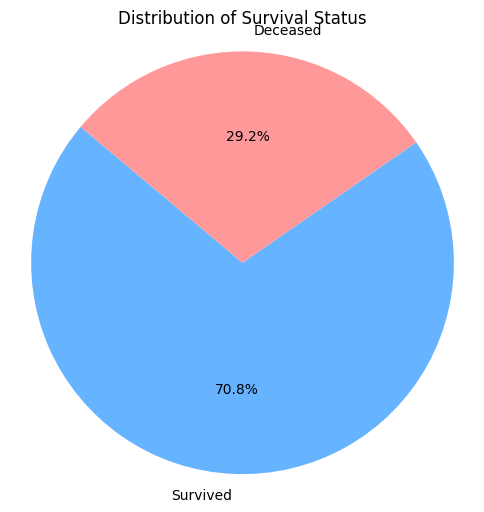

<ipython-input-170-60485e29a0c4>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survival_Status', y='Age', data=df_vis, palette='Set2')


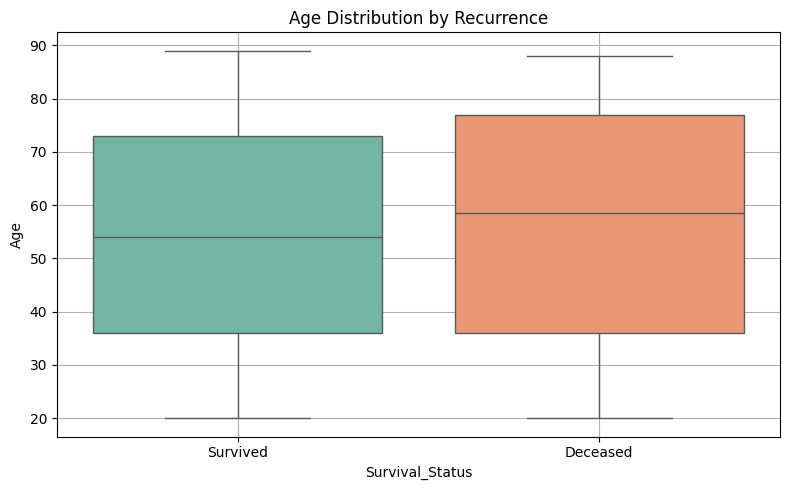

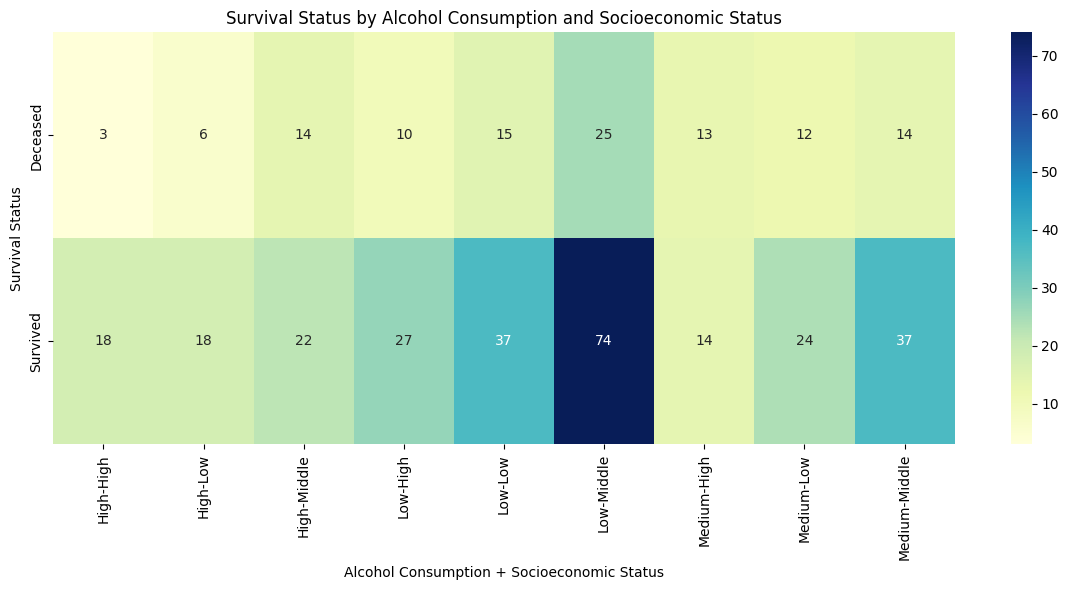

In [170]:

#visulaizing Y1_og (survival instincts)
import matplotlib.pyplot as plt
import pandas as pd

# Assuming Y1_og contains the original labels like "Alive", "Deceased", etc.
#converting the numPy into a series
y1_series = pd.Series(Y1_og)

# Get value counts
survival_counts = y1_series.value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(survival_counts, labels=survival_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999','#99ff99'])
plt.title("Distribution of Survival Status")
plt.axis('equal')  # Equal aspect ratio ensures that pie is a circle
plt.show()

################################################################################


#bi variate - boxplot
df_vis = pd.DataFrame({
    'Survival_Status': Y1_og,
    'Age': X_og[:, 0]  # Replace with actual index for Age
})

# Optional: convert to string labels for clarity
df_vis = df_vis.astype(str)
df_vis['Age'] = pd.to_numeric(df_vis['Age'])

# Box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Survival_Status', y='Age', data=df_vis, palette='Set2')
plt.title('Age Distribution by Recurrence')
plt.xlabel('Survival_Status')
plt.ylabel('Age')
plt.grid(True)
plt.tight_layout()
plt.show()

################################################################################

#create dataframe for the heatmap
df_vis = pd.DataFrame({
    'Survival_Status': Y1_og,
    'Alcohol_Consumption': X_og[:, 16],  # choose index of the column
    'Socioeconomic_Status': X_og[:, 5]  # choose index of the column
})

#plot the heatmap
heatmap_data = pd.crosstab(
    index=[df_vis['Survival_Status']],
    columns=[df_vis['Alcohol_Consumption'], df_vis['Socioeconomic_Status']]
)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Survival Status by Alcohol Consumption and Socioeconomic Status")
plt.xlabel("Alcohol Consumption + Socioeconomic Status")
plt.ylabel("Survival Status")
plt.tight_layout()
plt.show()

<ipython-input-171-b7629a7d6d72>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y2_series, palette='pastel')


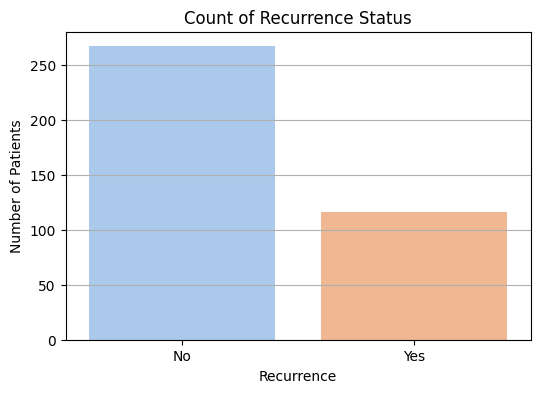

<ipython-input-171-b7629a7d6d72>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Recurrence', y='Age', data=df_vis, palette='Set2')


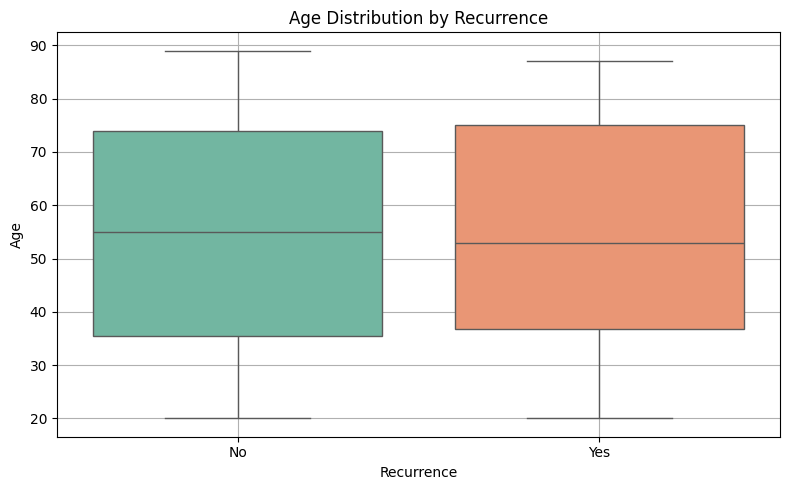

    count unique  top freq
Age                       
20      5      2   No    3
21      4      2   No    3
22      7      2   No    6
23      2      1   No    2
24      5      2  Yes    4
..    ...    ...  ...  ...
85      4      2   No    3
86      1      1  Yes    1
87     10      2   No    7
88      4      1   No    4
89      7      1   No    7

[69 rows x 4 columns]


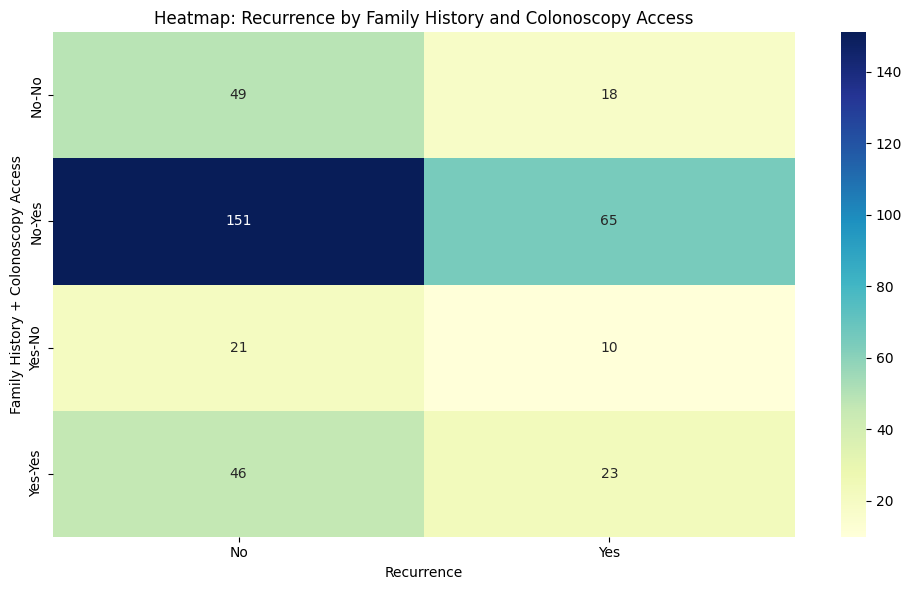

In [171]:

import pandas as pd
import matplotlib.pyplot as plt

# Convert to a pandas Series (if it's a NumPy array)
y2_series = pd.Series(Y2_og)

# Count values
recurrence_counts = y2_series.value_counts()

#bar plot
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(x=y2_series, palette='pastel')
plt.title("Count of Recurrence Status")
plt.xlabel("Recurrence")
plt.ylabel("Number of Patients")
plt.grid(axis='y')
plt.show()

################################################################################
#bi-variate visualization

df_vis = pd.DataFrame({
    'Recurrence': Y2_og,
    'Age': X_og[:, 0]  # Replace with actual index for Age
})

# Optional: convert to string labels for clarity
df_vis = df_vis.astype(str)
df_vis['Age'] = pd.to_numeric(df_vis['Age'])

# Box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Recurrence', y='Age', data=df_vis, palette='Set2')
plt.title('Age Distribution by Recurrence')
plt.xlabel('Recurrence')
plt.ylabel('Age')
plt.grid(True)
plt.tight_layout()
plt.show()

print(df_vis.groupby('Age')['Recurrence'].describe())

################################################################################

#Heatmap
df_vis = pd.DataFrame({
    'Recurrence': Y2_og,
    'Family_History': X_og[:, 6],         # Replace with actual index
    'Colonoscopy_Access': X_og[:, 10] # Replace with actual index
})

# Convert to strings if needed
df_vis = df_vis.astype(str)

# Create a crosstab grouped by Family_History & Colonoscopy_Access vs Recurrence
ctab = pd.crosstab(
    index=[df_vis['Family_History'], df_vis['Colonoscopy_Access']],
    columns=df_vis['Recurrence']
)

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ctab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Recurrence by Family History and Colonoscopy Access')
plt.xlabel('Recurrence')
plt.ylabel('Family History + Colonoscopy Access')
plt.tight_layout()
plt.show()

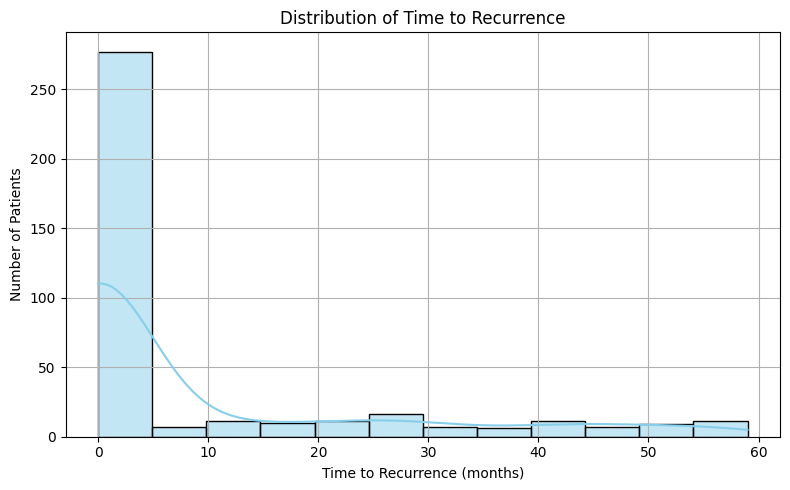

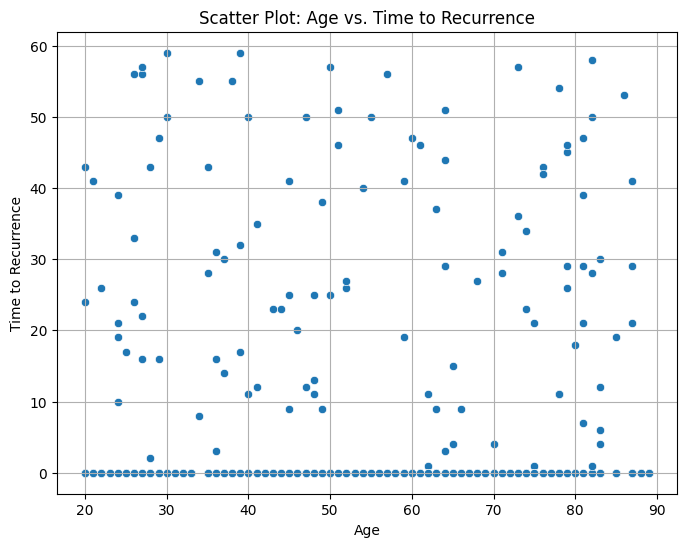

<ipython-input-172-b29b61546b99>:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Smoking_Status', y='Time_to_Recurrence', data=df_vis, palette='coolwarm')


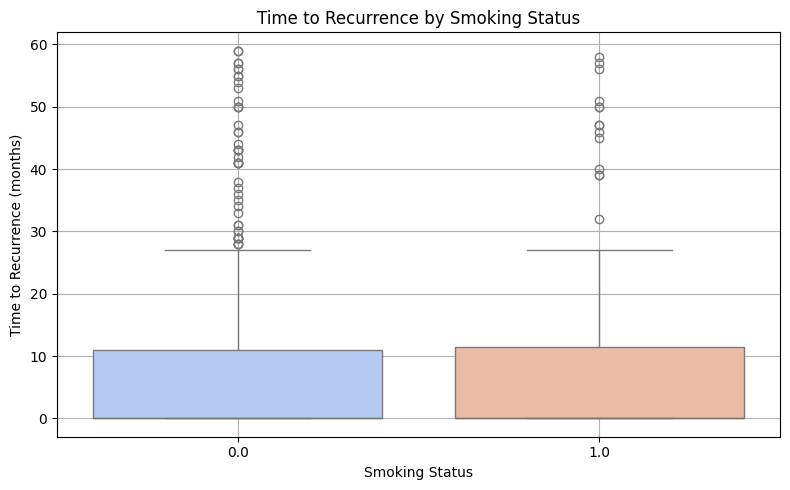

                count      mean        std  min  25%  50%   75%   max
Smoking_Status                                                       
0.0             288.0  8.614583  15.981285  0.0  0.0  0.0  11.0  59.0
1.0              95.0  9.400000  17.261690  0.0  0.0  0.0  11.5  58.0


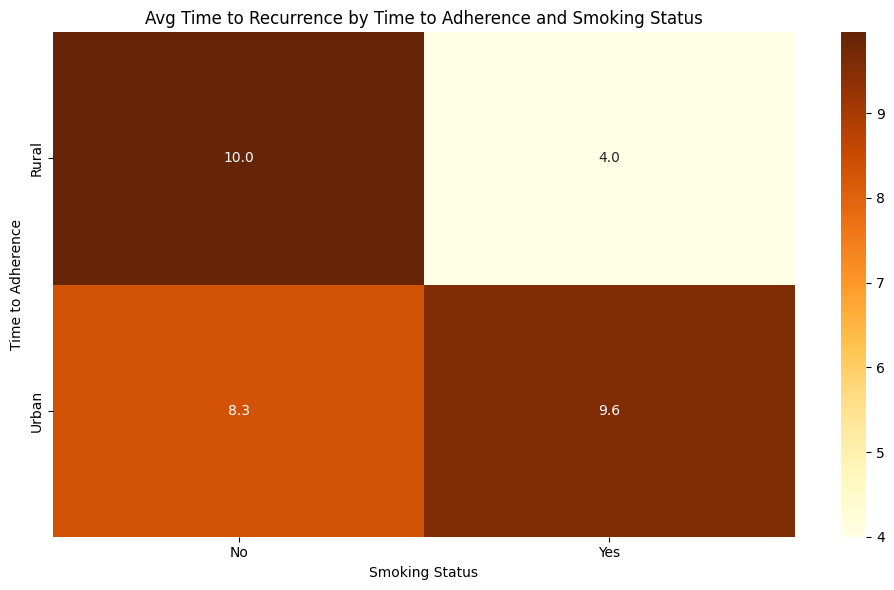

In [172]:
#Time_to_recuurence

import pandas as pd
import matplotlib.pyplot as plt

# Convert to a pandas Series (if it's a NumPy array)
y3_series = pd.Series(Y3_og)


# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(y3_series, bins=12, kde=True, color='skyblue')  # kde adds a smooth curve
plt.title('Distribution of Time to Recurrence')
plt.xlabel('Time to Recurrence (months)')
plt.ylabel('Number of Patients')
plt.grid(True)
plt.tight_layout()
plt.show()



# Extract age from X_og (assuming age is the first column)
age = X_og[:, 0]

# Create DataFrame
df = pd.DataFrame({
    'Age': age,
    'Time_to_Recurrence': Y3_og
})


# Plot scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Time_to_Recurrence', data=df)
plt.title('Scatter Plot: Age vs. Time to Recurrence')
plt.xlabel('Age')
plt.ylabel('Time to Recurrence')
plt.grid(True)
plt.show()




#Follow_Up_Adherence in X_og
smoking_index = 15  # e.g., 7 or 10

# Create DataFrame
df_vis = pd.DataFrame({
    'Smoking_Status': X[:, smoking_index],
    'Time_to_Recurrence': y3_series
})

# Ensure correct data types
df_vis['Smoking_Status'] = df_vis['Smoking_Status'].astype(str)
df_vis['Time_to_Recurrence'] = pd.to_numeric(df_vis['Time_to_Recurrence'], errors='coerce')

# Plot the boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Smoking_Status', y='Time_to_Recurrence', data=df_vis, palette='coolwarm')
plt.title('Time to Recurrence by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Time to Recurrence (months)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(df_vis.groupby('Smoking_Status')['Time_to_Recurrence'].describe())

######################################

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Construct DataFrame using numpy arrays
df_vis = pd.DataFrame({
    'Time_to_Recurrence': Y3_og,
    'Time_to_Adherence': X_og[:, 4],    # Adjust index if different
    'Smoking_Status': X_og[:, 7]        # Adjust index if different
})

# Convert categories to strings for labeling
df_vis = df_vis.astype(str)
df_vis['Time_to_Recurrence'] = pd.to_numeric(df_vis['Time_to_Recurrence'], errors='coerce')

# Create pivot table for mean time to recurrence
pivot_table = df_vis.pivot_table(
    index='Time_to_Adherence',
    columns='Smoking_Status',
    values='Time_to_Recurrence',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrBr')
plt.title('Avg Time to Recurrence by Time to Adherence and Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Time to Adherence')
plt.tight_layout()
plt.show()


In [173]:
#box plot is biased.

In [174]:
#dexided to make use of dataframes ball it
from scipy.stats import chi2_contingency
import pandas as pd

# Create DataFrame
df_chi1 = pd.DataFrame({
    'Recurrence': Y2_og,
    'Family_History': X_og[:, 6]  # replace with correct index
})

# Crosstab
ctab1 = pd.crosstab(df_chi1['Recurrence'], df_chi1['Family_History'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ctab1)

print(f"Chi-square Test Recurrence vs Family History:")
print(f"Chi2 = {chi2:.3f}, p-value = {p:.4f}")


#Significant association between the two categorical variables if p-value < 0.05
#so this does not have any statistical accociation

Chi-square Test Recurrence vs Family History:
Chi2 = 0.314, p-value = 0.5753


In [175]:
# Create DataFrame
df_chi2 = pd.DataFrame({
    'Survival_Status': Y1_og,
    'Alcohol_Consumption': X_og[:, 16]  # replace with correct index
})

# Crosstab
ctab2 = pd.crosstab(df_chi2['Survival_Status'], df_chi2['Alcohol_Consumption'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ctab2)

print(f"Chi-square Test Survival Status vs Alcohol Consumption:")
print(f"Chi2 = {chi2:.3f}, p-value = {p:.4f}")

#no

Chi-square Test Survival Status vs Alcohol Consumption:
Chi2 = 2.024, p-value = 0.3634


In [176]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

import pandas as pd

# Quick simple DataFrame using the correct columns
df_corr = pd.DataFrame({
    'BMI': X_og[:, 13],  # replace bmi_index
    'Time_to_Recurrence': Y3    # assuming Y3 is already the right array
})

df_corr['BMI'] = pd.to_numeric(df_corr['BMI'])
df_corr['Time_to_Recurrence'] = pd.to_numeric(df_corr['Time_to_Recurrence'])

from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_p = pearsonr(df_corr['BMI'], df_corr['Time_to_Recurrence'])
spearman_corr, spearman_p = spearmanr(df_corr['BMI'], df_corr['Time_to_Recurrence'])

print(f"Pearson Correlation: r = {pearson_corr:.3f}, p = {pearson_p:.4f}")
print(f"Spearman Correlation: r = {spearman_corr:.3f}, p = {spearman_p:.4f}")

#no significant

Pearson Correlation: r = 0.019, p = 0.7149
Spearman Correlation: r = 0.026, p = 0.6077


In [177]:
#sample t test
from scipy.stats import ttest_1samp
import numpy as np

# Assuming Y3 or y3_series is Time_to_Recurrence
pop_mean = 9.026  # Assumed population mean in months

# Run one-sample t-test
t_stat, p_value = ttest_1samp(y3_series, pop_mean)

print(f"T-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

#p > 0.05	Sample is similar to the population (not significantly different)
#fail to reject the null hypothesis

T-statistic = -0.260, p-value = 0.7948




Data is scattered, not linear Non-linear model (Decision Tree, etc.) Many zeros in Y Consider binarizing (0 vs >0) or adjusting model Linear model won't help Use tree-based or neighbor-based methods

Decision Tree Regressor Can split based on age ranges (e.g. "<40", "40-70", "70+") and give different average predictions Random Forest Regressor Can average many decision trees and reduce noise KNN Regressor Can use local neighbors to predict Time_to_Recurrence

There’s no clear straight-line relationship between Age and Time_to_Recurrence. Some older patients have long recurrence time, some younger ones do too, and many have zero.

So, using Linear Regression here wouldn't make sense — the line will either be flat or completely miss the data.

"This scatter plot shows no strong linear trend between Age and Time to Recurrence — the points are widely spread, and a large number of values are zero. This suggests that the relationship is non-linear, and therefore models like Decision Tree or Random Forest are better suited than Linear Regression in this case."

-showcase the failed regression then do the suggested.


In [178]:
# Only select Age from X
X_age = X_og[:, [0]]  # double square brackets to keep it as a DataFrame
# we used the not encoded since we want a specific column

# Split BMI-only data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_age, Y3_og, test_size=0.2, random_state=44)

# Train the model
from sklearn.linear_model import LinearRegression

age_model = LinearRegression()
age_model.fit(X_train, y_train)

# Predict
y_pred = age_model.predict(X_test)


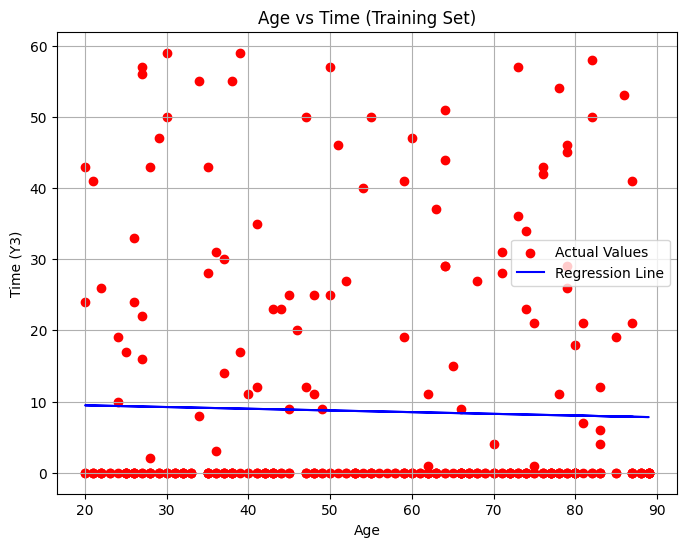

In [179]:
import matplotlib.pyplot as plt

# Visualize the Training Set
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, color='red', label='Actual Values')  # Actual training points
plt.plot(X_train, age_model.predict(X_train), color='blue', label='Regression Line')  # Predicted regression line
plt.title('Age vs Time (Training Set)')
plt.xlabel('Age')
plt.ylabel('Time (Y3)')
plt.legend()
plt.grid(True)
plt.show()


In [180]:
#regression equation
#getting the final regression equation
print("slope (coefficient):", age_model.coef_[0])
print("intercept:", age_model.intercept_)



slope (coefficient): -0.023916587077468777
intercept: 9.944538677966479


In [181]:
#using the training set we made already at the begining
#multiple regression

from sklearn.linear_model import LinearRegression

# Create the model
multi_model = LinearRegression()

# Train the model on the scaled training set
multi_model.fit(X_train_scaled, y_train)

# Predict on the scaled testing set
y_pred = multi_model.predict(X_test_scaled)

# Evaluate the model
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R\u00b2 Score: {r2:.3f}")
print(f"Mean Squared Error: {mse:.3f}")


R² Score: -0.221
Mean Squared Error: 338.282


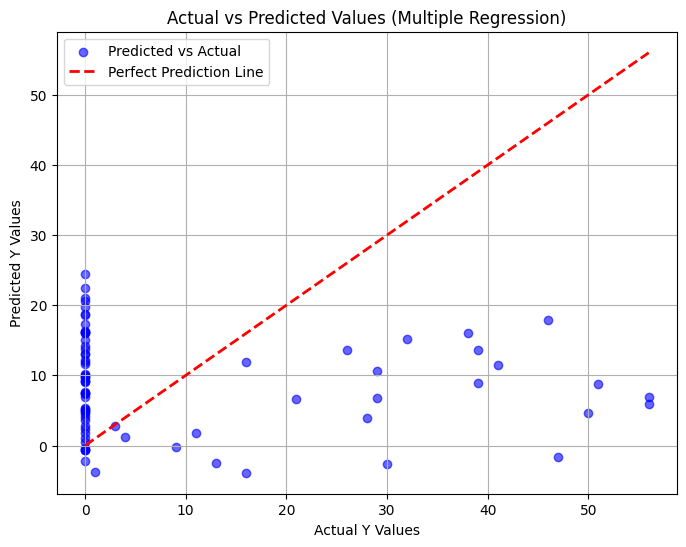

In [182]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs Predicted Values (Multiple Regression)')
plt.xlabel('Actual Y Values')
plt.ylabel('Predicted Y Values')
plt.legend()
plt.grid(True)
plt.show()


compare alll classification methods

In [183]:
# CLASSIFICATION MODELS FOR Y1, Y2, Y3_cat
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Convert Y3 into binary classification: 0 = early (≤12 months), 1 = late
Y3_cat_train = (Y3_train > 12).astype(int)
Y3_cat_test = (Y3_test > 12).astype(int)

# Classifier setup
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=44)
}

# Dataset dictionary
targets = {
    "Y1 (Survival_Status)": (Y1_train, Y1_test),
    "Y2 (Recurrence)": (Y2_train, Y2_test),
    "Y3_cat (Time_to_Recurrence > 12mo)": (Y3_cat_train, Y3_cat_test)
}

print("==== CLASSIFICATION MODEL PERFORMANCE ====\n")

for target_name, (y_train, y_test) in targets.items():
    print(f"\nTarget: {target_name}")
    for model_name, model in models.items():
        if model_name in ["Logistic Regression", "KNN"]:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        print(f"\n{model_name} Accuracy: {acc:.2f}")
        print("Confusion Matrix:\n", cm)
        print("-" * 40)


==== CLASSIFICATION MODEL PERFORMANCE ====


Target: Y1 (Survival_Status)

Logistic Regression Accuracy: 0.64
Confusion Matrix:
 [[ 2 26]
 [ 2 47]]
----------------------------------------

KNN Accuracy: 0.61
Confusion Matrix:
 [[ 1 27]
 [ 3 46]]
----------------------------------------

Naive Bayes Accuracy: 0.64
Confusion Matrix:
 [[ 0 28]
 [ 0 49]]
----------------------------------------

Decision Tree Accuracy: 0.60
Confusion Matrix:
 [[ 4 24]
 [ 7 42]]
----------------------------------------

Target: Y2 (Recurrence)

Logistic Regression Accuracy: 0.57
Confusion Matrix:
 [[42 10]
 [23  2]]
----------------------------------------

KNN Accuracy: 0.58
Confusion Matrix:
 [[43  9]
 [23  2]]
----------------------------------------

Naive Bayes Accuracy: 0.68
Confusion Matrix:
 [[52  0]
 [25  0]]
----------------------------------------

Decision Tree Accuracy: 0.69
Confusion Matrix:
 [[46  6]
 [18  7]]
----------------------------------------

Target: Y3_cat (Time_to_Recurrence > 12m

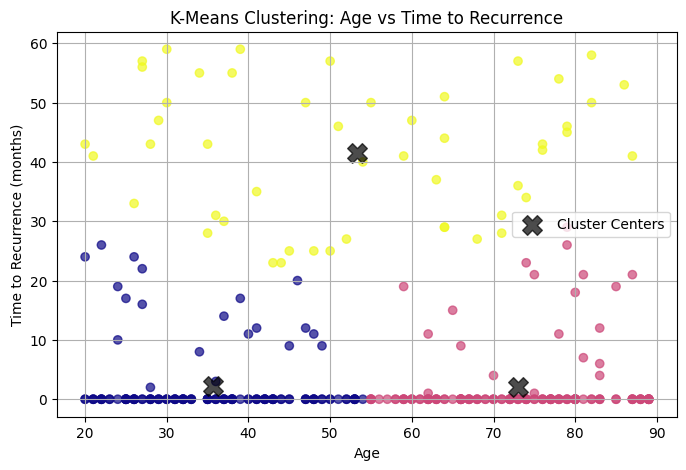

In [184]:
from sklearn.cluster import KMeans

# Age is column index 0 in X_train
age_train = X_train[:, 0]

# Stack Age and Y3 into 2D data for clustering
X_cluster_age = np.column_stack((age_train, Y3_train))

# Perform KMeans
kmeans_age = KMeans(n_clusters=3, random_state=44)
clusters_age = kmeans_age.fit_predict(X_cluster_age)

# Get the cluster centers
centers = kmeans_age.cluster_centers_

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_cluster_age[:, 0], X_cluster_age[:, 1], c=clusters_age, cmap='plasma', alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.7, marker='X', label='Cluster Centers')
plt.xlabel("Age")
plt.ylabel("Time to Recurrence (months)")
plt.title("K-Means Clustering: Age vs Time to Recurrence")
plt.grid(True)
plt.legend()
plt.show()


"The K-Means clustering on Age vs. Time to Recurrence revealed three distinct clusters. One consisted of mostly younger patients with lower recurrence times, another of older patients with similar behavior, and a third showing mixed ages but consistently high recurrence durations. This highlights potential age-based subgroups that could inform tailored monitoring or intervention strategies."

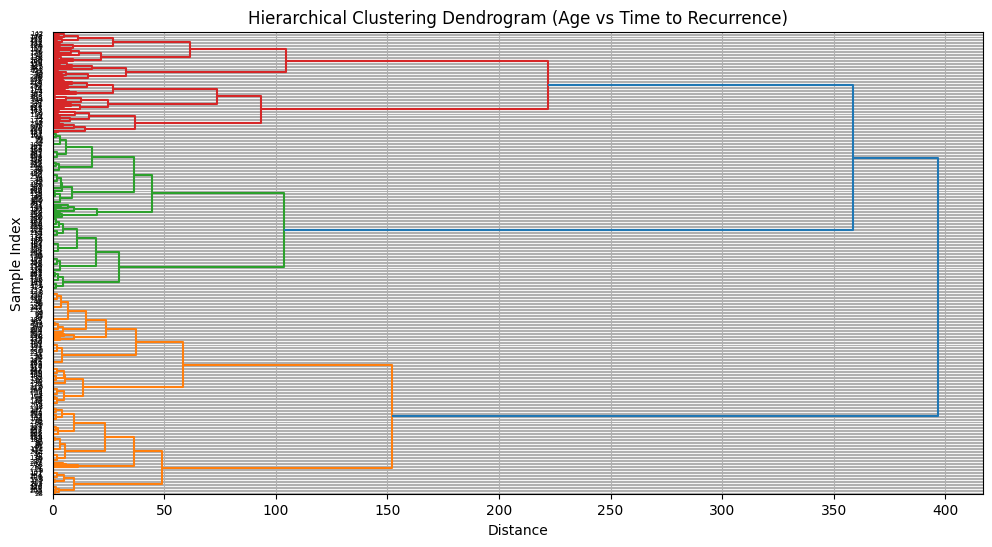

In [185]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Stack Age and Y3 into 2D data for clustering
X_cluster_age = np.column_stack((age_train, Y3_train))

# Perform hierarchical clustering
linked = linkage(X_cluster_age, method='ward')

# Plot the dendrogram horizontally
plt.figure(figsize=(12, 6))
dendrogram(linked,
           orientation='right',
           distance_sort='ascending',
           show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram (Age vs Time to Recurrence)')
plt.xlabel('Distance')
plt.ylabel('Sample Index')
plt.grid(True)
plt.show()
